breast cancer detection
-----------------------------------
accuracy: 0.947
-----------------------------------
top 8 important features:
mean concave points     0.704583
worst concave points    0.066901
worst radius            0.053295
worst perimeter         0.052474
mean texture            0.031395
worst texture           0.028196
concavity error         0.018908
concave points error    0.016234
dtype: float64


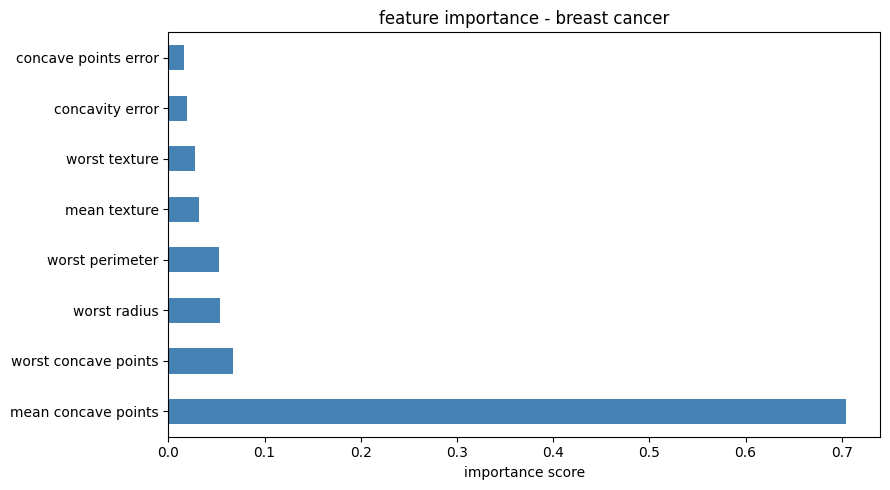

In [4]:
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(x_train, y_train)

print("breast cancer detection")
print("-" * 35)
print("accuracy:", round(model.score(x_test, y_test), 3))
print("-" * 35)

importance = pd.Series(
    model.feature_importances_,
    index=cancer.feature_names
).sort_values(ascending=False).head(8)

print("top 8 important features:")
print(importance)

plt.figure(figsize=(9, 5))
importance.plot(kind="barh", color="steelblue")
plt.title("feature importance - breast cancer")
plt.xlabel("importance score")
plt.tight_layout()
plt.show()